In [1]:
import json
import os
import pprint
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from pyalex import Works, config
from tqdm.notebook import tqdm

In [2]:
# PyAlex config
load_dotenv()
config.max_retries = 3
config.retry_backoff_factor = 0.1
config.email = os.getenv("EMAIL")  # OpenAlex polite pool

In [3]:
# Read list of topics from file
p_topics = Path("topics.json")
with p_topics.open("r") as fp:
    l_topics = json.load(fp).get("topics")

# Remove every key except of "id", "display_name" and "description"
topics = [
    {k: d[k] for k in ("id", "display_name", "description") if k in d}
    for d in l_topics
]

# Display the first topic as an example
topics[0]

{'id': 'https://openalex.org/T11881',
 'display_name': 'Crystallization and Solubility Studies',
 'description': 'This cluster of papers focuses on the crystallization processes and control, including topics such as nucleation, solubility, polymorphism, ultrasound-assisted crystallization, process analytical technology, crystal growth, pharmaceutical crystallization, continuous crystallization, and crystal engineering.'}

In [4]:
# Check if tagging has already been done, if so read from file
p_tagged_topics = Path("tagged_topics.json")
if p_tagged_topics.exists():
    print("Found cached version, reading from file")
    with p_tagged_topics.open("r") as fp:
        tagged_topics = json.load(fp)
else:
    # TODO: Fix import
    sys.path.append(os.path.expandvars("/home/$USER/code/ows_eo_kg"))
    from arango.client import ArangoClient
    from arango.database import StandardDatabase

    from gcmd_science_keywords.tagger import KeywordTagger

    # Establish connection to ArangoDB where taxonomy is stored
    arango_db: StandardDatabase = ArangoClient(hosts=os.getenv("HOST")).db(
        name="taxo",
        username="root",
        password=os.getenv("ARANGO_ROOT_PASSWORD"),
    )

    # Very low score so we can plot with more data
    tagger = KeywordTagger(arango_db, min_sen=0.1, min_agg=0.1)

    tagged_topics = []
    for topic in tqdm(topics):
        keywords = tagger.get_keywords(topic.get("description"))
        tagged_topics.append(
            {
                "topic_id": topic.get("id"),
                "topic_name": topic.get("display_name"),
                "topic_description": topic.get("description"),
                "highest_keyword_score": keywords[0][2],
                "assigned_keywords": keywords,
            }
        )

    # Save tagged topics to file
    with p_tagged_topics.open("w") as fp:
        json.dump(tagged_topics, fp=fp, indent=4)

# Display first item as example
tagged_topics[0]

Found cached version, reading from file


{'topic_id': 'https://openalex.org/T11881',
 'topic_name': 'Crystallization and Solubility Studies',
 'topic_description': 'This cluster of papers focuses on the crystallization processes and control, including topics such as nucleation, solubility, polymorphism, ultrasound-assisted crystallization, process analytical technology, crystal growth, pharmaceutical crystallization, continuous crystallization, and crystal engineering.',
 'highest_keyword_score': 0.28924902677536013,
 'assigned_keywords': [['HYDRATION',
   '2b1f870b-c679-4b6d-b02e-3eb005f0648d',
   0.28924902677536013],
  ['DISSOLUTION', '6628bfb9-c0e1-4281-9b1a-d213a9d5b2d8', 0.28445200324058534],
  ['MINERALS', '387a51ad-382f-4297-be72-fdd4bb0fe3f9', 0.25792027115821836],
  ['MINERAL FORMATION',
   'f6ce9d55-4183-4433-a615-4c4f01d7810b',
   0.23171696662902833],
  ['ION EXCHANGE',
   'ccbf4ef8-955b-4337-a45b-95affc360173',
   0.21436933279037476],
  ['IGNEOUS ROCK FORMATION',
   '984d4966-070d-4f8c-85e7-83bb0fd804a8',
   0.

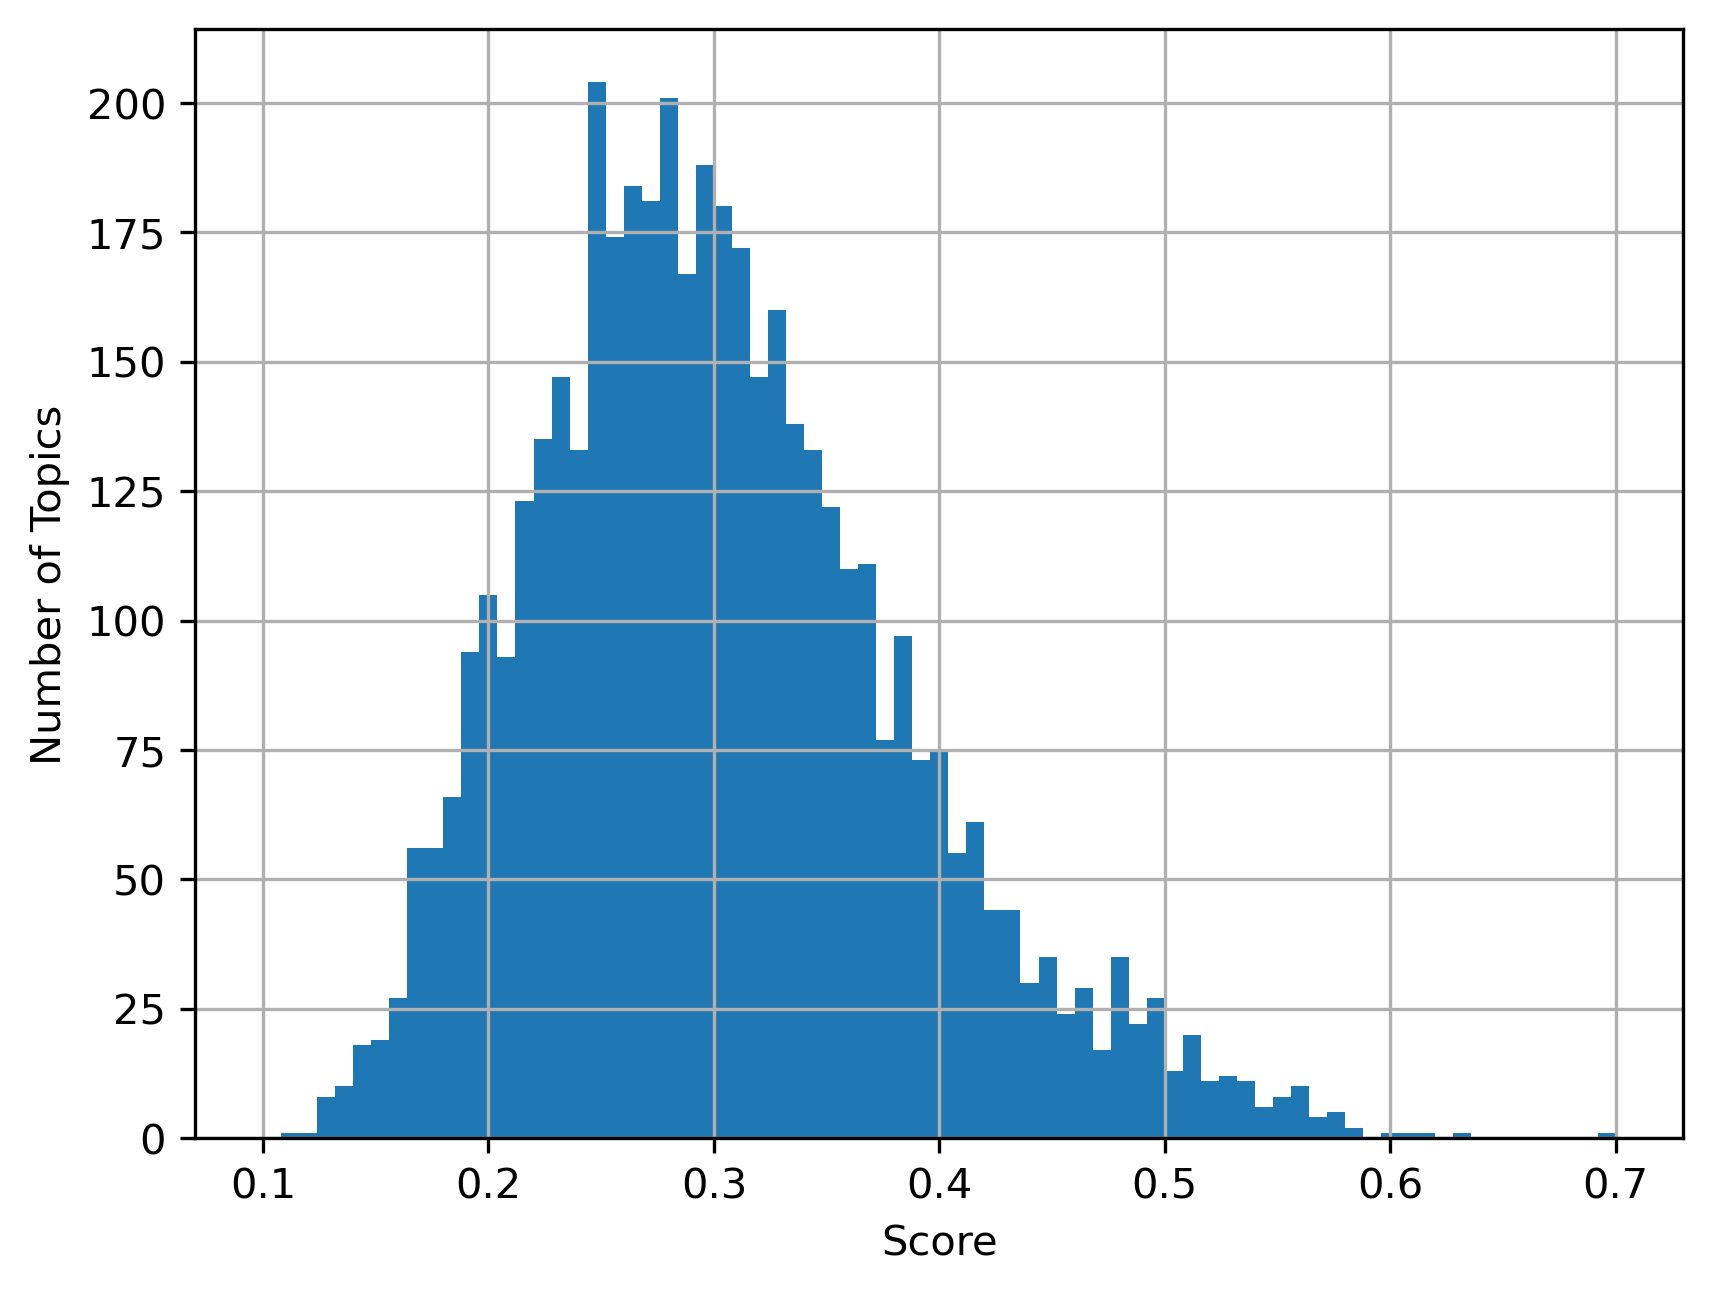

In [7]:
# Extract highest scores from tagged topics
scores = [
    topic.get("assigned_keywords")[0][2]
    for topic in tagged_topics
    if topic.get("assigned_keywords")
]

# Display distribution
plt.figure(dpi=300)
plt.hist(scores, bins=75, range=(0.1, 0.7))
# plt.title("Distribution of highest keyword scores")
plt.xlabel("Score")
plt.ylabel("Number of Topics")
plt.grid(True)
plt.savefig("oa_topics_plot.svg")
plt.show()

In [6]:
plt.savefig("oa_topics_plot.svg")

<Figure size 640x480 with 0 Axes>

In [6]:
def count_works(topic_id: str) -> tuple[int, int, int]:
    """Count the number of relevant works for a given topic."""
    articles = (
        Works()
        .filter(primary_topic={"id": topic_id})
        .filter(has_abstract=True)
        .filter(from_publication_date="1984-04-07")  # Oldest SATC Collection
        .filter(language="en")
        .filter(type="article")
        .filter(locations={"is_accepted": True})  # Peer reviewed
        .count()
    )

    datasets_all = (
        Works()
        .filter(primary_topic={"id": topic_id})
        .filter(has_abstract=True)
        .filter(from_publication_date="1984-04-07")
        .filter(type="dataset")
        .count()
    )

    datasets_en = (
        Works()
        .filter(primary_topic={"id": topic_id})
        .filter(has_abstract=True)
        .filter(from_publication_date="1984-04-07")
        .filter(language="en")
        .filter(type="dataset")
        .count()
    )

    return articles, datasets_all, datasets_en

In [7]:
def get_relevant_work_counts_df(filepath: Path) -> pd.DataFrame:
    """Get the DataFrame with relevant works of topics.

    This function returns a DataFrame containing topics and the
    associated number of relevant works. A work is relevant if captured
    by the 'count_works' function.
    """
    csv_path = filepath.with_suffix(".csv")
    if csv_path.exists():
        print("Found cached version, reading from memory")
        return pd.read_csv(csv_path)

    print(f"No cached file {csv_path} found, creating new DataFrame")
    works_per_topic = [
        (
            topic.get("topic_id"),
            topic.get("topic_name"),
            topic.get("topic_description"),
            topic.get("highest_keyword_score"),
            *(count_works(topic.get("topic_id"))),
        )
        for topic in tqdm(tagged_topics)
    ]

    df = pd.DataFrame(
        works_per_topic,
        columns=[
            "topic_id",
            "topic_name",
            "topic_description",
            "highest_keywords_score",
            "articles",
            "datasets_all",
            "datasets_en",
        ],
    )

    print("Saving DataFrame to memory")
    df.to_csv(csv_path, index=False)
    return df

In [8]:
df = get_relevant_work_counts_df(Path("relevant_works_count.csv"))
df.head()

Found cached version, reading from memory


,topic_id,topic_name,topic_description,highest_keyword_score,articles,datasets_all,datasets_en
0,https://openalex.org/T11881,Crystallization and Solubility Studies,This cluster of papers focuses on the crystall...,0.289249,3891,722250,722247
1,https://openalex.org/T11475,French Urban and Social Studies,This cluster of papers explores the intersecti...,0.433906,2840,1187,254
2,https://openalex.org/T13445,American Constitutional Law and Politics,This cluster of papers explores the developmen...,0.231991,6978,1218,1072
3,https://openalex.org/T10165,Classical Antiquity Studies,This cluster of papers explores various aspect...,0.379585,5996,1050,878
4,https://openalex.org/T10362,Biblical Studies and Interpretation,This cluster of papers focuses on biblical stu...,0.270088,11112,242,227


In [9]:
print("Threshold | Topics | Topics Loss (%) | Works (all) | Works (en) | Works Loss (all/en) (%)")  # noqa: E501
print("-" * 89)

for threshold in np.round(np.arange(0.1, 0.5, 0.025), 3):
    count_topics, count_works_all, count_works_en = [0] * 3
    total_topics = len(df)
    total_works_all, total_works_en = [0] * 2

    for _, row in df.iterrows():
        total_works_all += row["articles"] + row["datasets_all"]
        total_works_en += row["articles"] + row["datasets_en"]
        if row["highest_keyword_score"] >= threshold:
            count_topics += 1
            count_works_all += row["articles"] + row["datasets_all"]
            count_works_en += row["articles"] + row["datasets_en"]

    topics_loss = 100 * (total_topics - count_topics) / total_topics
    works_loss_all = 100 * (total_works_all - count_works_all) / total_works_all
    works_loss_en = 100 * (total_works_en - count_works_en) / total_works_en

    print(f"{threshold:9.3f} | {count_topics:>6,} | {topics_loss:14.2f}% | {count_works_all:>11,} | {count_works_en:>10,} | {works_loss_all:>10.2f}%   / {works_loss_en:>6.2f}%")  # noqa: E501


Threshold | Topics | Topics Loss (%) | Works (all) | Works (en) | Works Loss (all/en) (%)
-----------------------------------------------------------------------------------------
    0.100 |  4,516 |           0.00% |  28,573,425 | 28,398,134 |       0.00%   /   0.00%
    0.125 |  4,514 |           0.04% |  28,538,985 | 28,363,716 |       0.12%   /   0.12%
    0.150 |  4,475 |           0.91% |  28,279,305 | 28,104,281 |       1.03%   /   1.03%
    0.175 |  4,353 |           3.61% |  27,349,236 | 27,189,833 |       4.28%   /   4.25%
    0.200 |  4,100 |           9.21% |  25,698,915 | 25,542,705 |      10.06%   /  10.05%
    0.225 |  3,760 |          16.74% |  23,626,987 | 23,476,879 |      17.31%   /  17.33%
    0.250 |  3,271 |          27.57% |  20,600,527 | 20,457,299 |      27.90%   /  27.96%
    0.275 |  2,709 |          40.01% |  17,272,600 | 17,140,409 |      39.55%   /  39.64%
    0.300 |  2,125 |          52.95% |  13,439,863 | 13,319,195 |      52.96%   /  53.10%
    0.325 

In [10]:
# TODO: Plot these distributions

In [11]:
def get_samples(lower: float, upper: float, n: int = 20) -> list[dict]:
    """Get n random topics in range."""
    filtered_topics = [
        topic for topic in tagged_topics
        if lower < topic.get("highest_keyword_score") <= upper
    ]

    return random.sample(filtered_topics, min(n, len(filtered_topics)))

In [12]:
start = 0.2
stop = 0.5
step = 0.025

for threshold in np.round(np.arange(start, stop, step), 3):
    samples = get_samples(threshold, threshold + step)
    print(f"Score range: {threshold} - {round((threshold + step), 3)}\n")
    for sample in samples:

        d = {
            "topic_name": sample.get("topic_name"),
            "topic_description": sample.get("topic_description"),
            "best_keyword": (sample.get("assigned_keywords")[0][0], f"{sample.get("assigned_keywords")[0][-1]:.3f}")
        }

        pprint.pprint(d, width=120, compact=True, sort_dicts=False)

    print("\n\n\n")

Score range: 0.2 - 0.225

{'topic_name': 'High-Velocity Impact and Material Behavior',
 'topic_description': 'This cluster of papers focuses on the dynamic material behavior of various metals and alloys '
                      'under extreme loading conditions, including high strain rates, ballistic impact, adiabatic '
                      'shear localization, and projectile penetration. The research involves experimental techniques '
                      'such as Split Hopkinson Pressure Bar testing and numerical modeling to understand the '
                      'constitutive behavior, microstructural evolution, and thermomechanical response of materials '
                      'subjected to dynamic deformation.',
 'best_keyword': ('COMPOSITION/STRUCTURE', '0.203')}
{'topic_name': 'Obsessive-Compulsive Spectrum Disorders',
 'topic_description': 'This cluster of papers covers a wide range of topics related to obsessive-compulsive disorder '
                      '(OCD) and its relat